In [3]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib
matplotlib.use("Agg")
from pathlib import Path
import platform
import sys
import pandas as pd
import mne
from mne import Annotations

### Load signal annotations

In [4]:

def load_annotation_file(txt_path):  #1)
    """
    Charge un fichier d’annotations avec structure :
    <start_sec> <time_str> <stage_str> <code>
    Retourne les segments REM (début, fin) en secondes.
    """
    segments = []
    current_start = None

    with open(txt_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) >= 3:
            start_sec = float(parts[0])
            stage = parts[2].upper()

            if stage == 'REM':
                if current_start is None:
                    current_start = start_sec
            else:
                if current_start is not None:
                    segments.append((current_start, start_sec))
                    current_start = None

    # Fin du fichier
    if current_start is not None:
        segments.append((current_start, start_sec))

    return segments


def extract_rem_segments(txt_path): #2)
    return load_annotation_file(txt_path)

def load_signals_and_annotations(edf_path, annot_path): #3)
    raw = mne.io.read_raw_edf(edf_path, preload=True)
    rem_segments = extract_rem_segments(annot_path)
    print(f"Fichiers détectés : {edf_path} + {annot_path}")
    print(f"Durée fichier EDF : {raw.times[-1]:.2f} secondes")
    print(f"Premier segment REM à t={rem_segments[0][0]:.2f} secondes")

    return raw, rem_segments


### epochs REM de 4s

In [5]:
def segment_rem_in_windows(raw, rem_segments, window_sec=4, step_sec=2):
    """
    Découpe les segments REM fournis en fenêtres glissantes, avec debug.

    Args:
        raw (mne.io.Raw): objet Raw EEG complet
        rem_segments (list): liste de tuples (start_sec, end_sec) des périodes REM
        window_sec (float): durée d'une fenêtre (en secondes)
        step_sec (float): pas de décalage entre fenêtres (en secondes)

    Returns:
        list of mne.io.Raw: fenêtres extraites du signal
    """
    windows = []
    print(f"[INFO] Fenêtrage en fenêtres de {window_sec}s avec pas de {step_sec}s.")

    for seg_idx, (start, end) in enumerate(rem_segments):
        if end - start < window_sec:
            print(f"[WARNING] Segment REM #{seg_idx} trop court ({end - start:.2f}s), ignoré.")
            continue

        print(f"[INFO] Segment REM #{seg_idx}: de {start:.2f}s à {end:.2f}s")
        t = start
        while t + window_sec <= end:
            print(f"  >>> Fenêtre : tmin={t:.2f}s, tmax={t + window_sec:.2f}s")
            try:
                epoch = raw.copy().crop(tmin=t, tmax=t + window_sec).load_data()
                windows.append(epoch)
            except Exception as e:
                print(f"[ERROR] Impossible de couper la fenêtre [{t:.2f}s - {t + window_sec:.2f}s] : {e}")
            t += step_sec

    print(f"[INFO] Total de {len(windows)} fenêtres extraites.")
    return windows

### OEG criteria

In [6]:

def detect_eog_microstate(win, sfreq=250.0):
    """
    Classe une fenêtre REM de 4 s comme "phasic", "tonic", ou "ignore"
    selon la section 2.2 de l'article (Simor et al., 2021).

    Critères :
    - EOG filtré entre 0.3–10 Hz
    - "phasic" si ≥2 déflexions >150 µV et <500 ms dans chacune des 2 moitiés (2s)
    - "tonic" si aucune déflexion >25 µV dans les 2 moitiés
    - sinon "ignore"
    """
    try:
        eog_picks = win.copy().pick_types(eog=True)
        data = eog_picks.get_data()
        if data.shape[0] == 0:
            return "ignore"

        signal = data[0]  # un seul canal EOG
        n_samples = signal.shape[0]
        half = n_samples // 2

        def count_em(segment):
            peaks, _ = find_peaks(np.abs(segment), height=150)
            if len(peaks) < 2:
                return 0
            peak_times = peaks / sfreq
            durations = np.diff(peak_times)
            return np.sum(durations < 0.5)

        em_left = count_em(signal[:half])
        em_right = count_em(signal[half:])

        if em_left >= 2 and em_right >= 2:
            return "phasic"
        if np.max(np.abs(signal[:half])) < 25 and np.max(np.abs(signal[half:])) < 25:
            return "tonic"
        return "ignore"

    except Exception as e:
        print(f"[EOG ERROR] {e}")
        return "ignore"


### Annotations

In [8]:

def annotate_microstates(raw, windows, labels, window_sec):
    """
    Ajoute des annotations 'phasic' / 'tonic' à l'objet raw.

    Args:
        raw (mne.io.Raw): signal EEG original
        windows (list of mne.io.Raw): fenêtres découpées
        labels (list of str): liste de labels ('phasic' / 'tonic') pour chaque fenêtre
        window_sec (float): durée de chaque fenêtre
    """
    onset = [win.first_time for win in windows]
    duration = [window_sec] * len(windows)
    description = labels

    annotations = Annotations(onset=onset, duration=duration, description=description)
    raw.set_annotations(annotations)
    print(f"[INFO] {len(annotations)} annotations 'tonic/phasic' ajoutées à raw.")


In [ ]:

system = platform.system()
if system == "Darwin":
    disque = "/Volumes/Crucial X6"
elif system == "Windows":
    disque = "D:"
elif system == "Linux":
    disque = "/media/darryld/Crucial X6"
else:
    raise RuntimeError("Système non supporté.")

edf_path = Path(f"{disque}/EEG/raw/MN143/MN143_raw.edf")
annot_path = Path(f"{disque}/EEG/raw/MN143/MN143_hypnoEXP.txt")

print("Chargement des fichiers...")
raw, rem_segments = load_signals_and_annotations(edf_path, annot_path)

print(f"{len(rem_segments)} segments REM détectés.")
windows = segment_rem_in_windows(raw, rem_segments, window_sec=4, step_sec=4)

labels = []
valid_windows = []
for win in windows:
    label = detect_eog_microstate(win)
    if label != "ignore":
        labels.append(label)
        valid_windows.append(win)

print(f"{len(valid_windows)} fenêtres retenues ({labels.count('phasic')} phasic / {labels.count('tonic')} tonic)")

annotate_microstates(raw, valid_windows, labels, window_sec=4)

output_dir = Path(f"{disque}/EEG/preprocessed/{montage}/full")
output_dir.mkdir(parents=True, exist_ok=True)
annotated_path = output_dir / f"{edf_path.stem}_annotated.fif"
raw.save(annotated_path, overwrite=True)
print(f"[OK] Fichier annoté sauvegardé : {annotated_path}")

df = pd.DataFrame({
    "tmin": [win.first_time for win in valid_windows],
    "tmax": [win.first_time + 4 for win in valid_windows],
    "label": labels
})
df.to_excel(output_dir / f"{edf_path.stem}_microstates.xlsx", index=False)
print("[OK] Export Excel terminé.")



In [ ]:
def detect_eog_microstate(win, sfreq=250.0):
    """
    Classe une fenêtre REM de 4 s comme "phasic", "tonic", ou "ignore"
    selon la section 2.2 de l'article (Simor et al., 2021).

    Critères :
    - EOG filtré entre 0.3–10 Hz
    - "phasic" si ≥2 déflexions >150 µV et <500 ms dans chacune des 2 moitiés (2s)
    - "tonic" si aucune déflexion >25 µV dans les 2 moitiés
    - sinon "ignore"
    """
    try:
        eog_picks = win.copy().pick_types(eog=True)
        data = eog_picks.get_data()
        if data.shape[0] == 0:
            return "ignore"

        signal = data[0]  # un seul canal EOG
        n_samples = signal.shape[0]
        half = n_samples // 2

        def count_em(segment):
            peaks, _ = find_peaks(np.abs(segment), height=150)
            if len(peaks) < 2:
                return 0
            peak_times = peaks / sfreq
            durations = np.diff(peak_times)
            return np.sum(durations < 0.5)

        em_left = count_em(signal[:half])
        em_right = count_em(signal[half:])

        if em_left >= 2 and em_right >= 2:
            return "phasic"
        if np.max(np.abs(signal[:half])) < 25 and np.max(np.abs(signal[half:])) < 25:
            return "tonic"
        return "ignore"

    except Exception as e:
        print(f"[EOG ERROR] {e}")
        return "ignore"

### Fichiers event (annotations manuelles)

In [4]:
from scipy.io import loadmat
import mne
import numpy as np

# Chemin vers ton fichier .mat
mat_path = "/home/darryld/Bureau/RB103/events_RB103_bipolaire.mat"
data = loadmat(mat_path)

# Affiche les clés disponibles
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'events'])


##### Inspection de la structure

In [5]:
events = data["events"]
print(type(events))
print(events.shape)
print(events.dtype)


<class 'numpy.ndarray'>
(1, 27)
[('label', 'O'), ('color', 'O'), ('epochs', 'O'), ('times', 'O'), ('reactTimes', 'O'), ('select', 'O'), ('channels', 'O'), ('notes', 'O')]


In [6]:
# Essayer d’afficher un élément pour voir la structure
import pprint
pprint.pprint(events[0])


array([(array(['<IMPEDANCE>'], dtype='<U11'), array([[0, 1, 0]], dtype=uint8), array([[1]], dtype=uint8), array([[16.125]]), array([], shape=(0, 0), dtype=uint8), array([[1]], dtype=uint8), array([], shape=(0, 0), dtype=uint8), array([], shape=(0, 0), dtype=uint8)),
       (array(['YF'], dtype='<U2'), array([[0.4, 0.4, 1. ]]), array([[1]], dtype=uint8), array([[158.1484375]]), array([], shape=(0, 0), dtype=uint8), array([[1]], dtype=uint8), array([], shape=(0, 0), dtype=uint8), array([], shape=(0, 0), dtype=uint8)),
       (array(['MO OK'], dtype='<U5'), array([[1. , 0.6, 0. ]]), array([[1]], dtype=uint8), array([[179.12109375]]), array([], shape=(0, 0), dtype=uint8), array([[1]], dtype=uint8), array([], shape=(0, 0), dtype=uint8), array([], shape=(0, 0), dtype=uint8)),
       (array(['MENTON OK'], dtype='<U9'), array([[0, 1, 1]], dtype=uint8), array([[1]], dtype=uint8), array([[190.7890625]]), array([], shape=(0, 0), dtype=uint8), array([[1]], dtype=uint8), array([], shape=(0, 0), dty

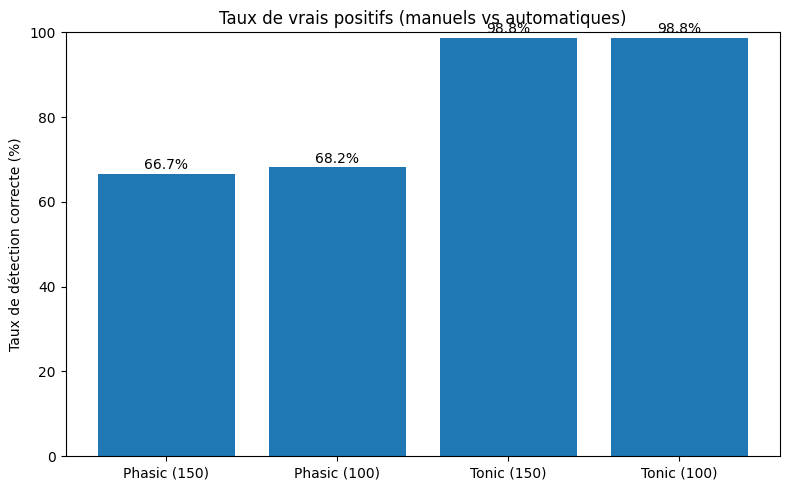

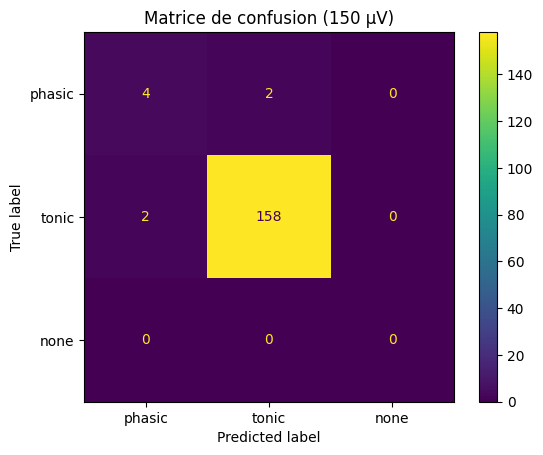

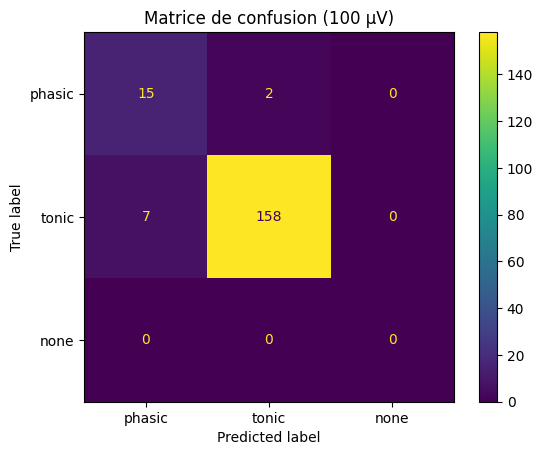

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
from pathlib import Path
from scipy.io import loadmat
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def load_manual_annotations(mat_file, label_name):
    """Charge les annotations manuelles depuis un fichier .mat Brainstorm"""
    mat = loadmat(mat_file, squeeze_me=True, struct_as_record=False)
    events = mat['events']
    for event in events:
        if event.label == label_name:
            starts = np.atleast_1d(event.times[0])
            ends = np.atleast_1d(event.times[1])
            return list(zip(starts, ends))
    return []

def is_match(start, end, intervals, tol=0.5):
    """Vérifie si l’intervalle automatique est contenu dans une annotation manuelle"""
    for man_start, man_end in intervals:
        if (man_start - tol) <= start and end <= (man_end + tol):
            return True
    return False

def analyze_detections(xlsx_path, manual_phasic, manual_tonic):
    """
    Compare les annotations automatiques aux annotations manuelles de type phasic et tonic.

    Permet d’évaluer la performance de l'algorithme de détection automatique 
    de micro-états REM (phasic/tonic) en les comparant aux annotations manuelles issues de Brainstorm.

    Paramètres
    ----------
    auto_df : pd.DataFrame
        DataFrame contenant les fenêtres détectées automatiquement.
        Doit avoir les colonnes suivantes :
        - 'tmin' : début de la fenêtre (en secondes)
        - 'tmax' : fin de la fenêtre (en secondes)
        - 'label' : 'phasic' ou 'tonic'

    manual_phasic : list of tuple(float, float)
        Liste des intervalles temporels (début, fin) annotés manuellement comme 'REM phasique' dans Brainstorm.

    manual_tonic : list of tuple(float, float)
        Liste des intervalles temporels (début, fin) annotés manuellement comme 'REM tonique' dans Brainstorm.
        True label (pour le moment) = fenêtre 'tonic' non contenue dans une fenêtre 'REM phasique' de Brainstorm. 
        (Lorsqu'on aura les annotations REM phasique, True label = fenêtre 'tonic' non contenue dans une fenêtre 'REM tonique'). 

    Retourne
    --------
    dict
        Un dictionnaire contenant :
        - 'confusion_matrix' : matrice 2x2 (TP, FP, FN, TN)
        - 'accuracy' : précision globale (entre 0 et 1)
        - 'precision_phasic' : précision de la classe 'phasic'
        - 'recall_phasic' : rappel de la classe 'phasic'
        - 'f1_phasic' : F1-score de la classe 'phasic'
        - 'details' : liste des fenêtres analysées avec pour chacune :
            - 'auto_label', 'manual_label', 'tmin', 'tmax'
    """
    df = pd.read_excel(xlsx_path)
    
    y_true = []
    y_pred = []

    # Remplir les vraies étiquettes selon inclusion dans manuel
    for _, row in df.iterrows():
        start, end, pred = row['tmin'], row['tmax'], row['label']
        if pred not in ["phasic", "tonic"]:
            continue

        if is_match(start, end, manual_phasic):
            true_label = "phasic"
        #elif is_match(start, end, manual_tonic):
        #    true_label = "tonic"
        else:
            #true_label = "none"
            true_label = "tonic"

        y_true.append(true_label)
        y_pred.append(pred)

    # Calcul taux de détection + faux positifs
    true_pos_phasic = sum((p == "phasic" and t == "phasic") for p, t in zip(y_pred, y_true))
    total_pred_phasic = sum(p == "phasic" for p in y_pred)
    fp_phasic = sum((p == "phasic" and t != "phasic") for p, t in zip(y_pred, y_true))

    true_pos_tonic = sum((p == "tonic" and t == "tonic") for p, t in zip(y_pred, y_true))
    total_pred_tonic = sum(p == "tonic" for p in y_pred)
    fp_tonic = sum((p == "tonic" and t != "tonic") for p, t in zip(y_pred, y_true))

    detection_stats = {
        "phasic": {
            "true_positive": true_pos_phasic,
            "false_positive": fp_phasic,
            "total_pred": total_pred_phasic,
            "rate": (true_pos_phasic / total_pred_phasic * 100) if total_pred_phasic > 0 else 0
        },
        "tonic": {
            "true_positive": true_pos_tonic,
            "false_positive": fp_tonic,
            "total_pred": total_pred_tonic,
            "rate": (true_pos_tonic / total_pred_tonic * 100) if total_pred_tonic > 0 else 0
        }
    }

    return detection_stats, y_true, y_pred

# Chemins des fichiers 
system = platform.system()
if system == "Darwin":
    disque = "/Volumes/Crucial X6"
elif system == "Windows":
    disque = "D:"
elif system == "Linux":
    disque = "/media/darryld/Crucial X6"
else:
    raise RuntimeError("Système non supporté.")

mat_path = Path(f"{disque}/EEG/raw/RB103/events_RB103_bipolaire.mat")
file_150 = Path(f"{disque}/EEG/raw/RB103/RB103_raw_microstates_150.xlsx")
file_100 = Path(f"{disque}/EEG/raw/RB103/RB103_raw_microstates_100.xlsx")

# Charger les annotations manuelles
manual_phasic = load_manual_annotations(mat_path, "REM phasique")
manual_tonic = load_manual_annotations(mat_path, "REM tonique") # >>> pas encore d'annotations manuelles "Tonique"

# Analyse 150 µV 
stats_150, y_true_150, y_pred_150 = analyze_detections(file_150, manual_phasic, manual_tonic)
# Analyse 100 µV 
stats_100, y_true_100, y_pred_100 = analyze_detections(file_100, manual_phasic, manual_tonic)

# Affichage barplot des vrais positifs
labels = ["Phasic (150)", "Phasic (100)", "Tonic (150)", "Tonic (100)"]
rates = [
    stats_150["phasic"]["rate"],
    stats_100["phasic"]["rate"],
    stats_150["tonic"]["rate"],
    stats_100["tonic"]["rate"]
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, rates)
plt.ylabel("Taux de détection correcte (%)")
plt.title("Taux de vrais positifs (manuels vs automatiques)")
plt.ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center')
plt.tight_layout()
plt.show()

# Affichage des matrices de confusion 
for title, y_true, y_pred in [("150 µV", y_true_150, y_pred_150), ("100 µV", y_true_100, y_pred_100)]:
    labels_cm = ["phasic", "tonic", "none"]
    cm = confusion_matrix(y_true, y_pred, labels=labels_cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cm)
    disp.plot(values_format='d')
    plt.title(f"Matrice de confusion ({title})")
    plt.show()


In [13]:
# Affichage des fenêtres mal classées (faux positifs et faux négatifs)
def afficher_erreurs(xlsx_path, y_true, y_pred, seuil):
    df = pd.read_excel(xlsx_path)
    erreurs = []
    bons = []

    for (true, pred), (_, row) in zip(zip(y_true, y_pred), df.iterrows()):
        ligne = {
            "tmin": row['tmin'],
            "tmax": row['tmax'],
            "auto_label": row['label'],
            "true_label": true
        }
        if true != pred:
            erreurs.append(ligne)
        else:
            bons.append(ligne)

    df_erreurs = pd.DataFrame(erreurs)
    df_bons = pd.DataFrame(bons)

    print(f"\nFenêtres mal détectées (seuil {seuil} µV) : {len(df_erreurs)}")
    display(df_erreurs.head(10))

    print(f"\nFenêtres bien détectées (seuil {seuil} µV) : {len(df_bons)}")
    display(df_bons.head(10))


# Affichage erreurs pour les deux seuils
afficher_erreurs(file_150, y_true_150, y_pred_150, 150)
afficher_erreurs(file_100, y_true_100, y_pred_100, 100)



Fenêtres mal détectées (seuil 150 µV) : 4


,tmin,tmax,auto_label,true_label
0,8356,8360,tonic,phasic
1,8384,8388,tonic,phasic
2,25216,25220,phasic,tonic
3,25782,25786,phasic,tonic



Fenêtres bien détectées (seuil 150 µV) : 162


,tmin,tmax,auto_label,true_label
0,7662,7666,tonic,tonic
1,7666,7670,tonic,tonic
2,8040,8044,tonic,tonic
3,8068,8072,tonic,tonic
4,8240,8244,tonic,tonic
5,8264,8268,tonic,tonic
6,8268,8272,tonic,tonic
7,8276,8280,tonic,tonic
8,8280,8284,tonic,tonic
9,8292,8296,tonic,tonic



Fenêtres mal détectées (seuil 100 µV) : 9


,tmin,tmax,auto_label,true_label
0,8356,8360,tonic,phasic
1,8384,8388,tonic,phasic
2,8468,8472,phasic,tonic
3,15164,15168,phasic,tonic
4,15690,15694,phasic,tonic
5,25216,25220,phasic,tonic
6,25284,25288,phasic,tonic
7,25782,25786,phasic,tonic
8,29062,29066,phasic,tonic



Fenêtres bien détectées (seuil 100 µV) : 173


,tmin,tmax,auto_label,true_label
0,7662,7666,tonic,tonic
1,7666,7670,tonic,tonic
2,8040,8044,tonic,tonic
3,8068,8072,tonic,tonic
4,8240,8244,tonic,tonic
5,8264,8268,tonic,tonic
6,8268,8272,tonic,tonic
7,8276,8280,tonic,tonic
8,8280,8284,tonic,tonic
9,8292,8296,tonic,tonic
